<a href="https://colab.research.google.com/github/radsrei/Caderno-Faculdade/blob/main/N1_AlgoritmoAvancado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Informaçõe básicas

In [31]:
%pip install opentelemetry-api opentelemetry-sdk
#declarações básicas
import pandas as pd
import matplotlib.pyplot as plt
import time

#Parte 2 - Algoritmo Ordenação

## Algoritmos O(n²)
###Bubble Sort

In [32]:
def bubble_sort(lista):
    n = len(lista)
    for i in range(n):
        # O último i elementos já estão no lugar
        for j in range(0, n - i - 1):
            if lista[j] > lista[j + 1]:
                # Troca os elementos de posição
                lista[j], lista[j + 1] = lista[j + 1], lista[j]
    return lista

###Insert Sort

In [33]:
def insertion_sort(lista):
    for i in range(1, len(lista)):
        chave = lista[i]
        j = i - 1
        # Move os elementos que são maiores que a chave para uma posição à frente
        while j >= 0 and chave < lista[j]:
            lista[j + 1] = lista[j]
            j -= 1
        lista[j + 1] = chave
    return lista

##Algoritmos O(n log n)
### Merge Sort

In [34]:
def merge_sort(lista):
    if len(lista) > 1:
        meio = len(lista) // 2
        esquerda = lista[:meio]
        direita = lista[meio:]

        # Chamada recursiva
        merge_sort(esquerda)
        merge_sort(direita)

        i = j = k = 0

        # Mesclando as partes
        while i < len(esquerda) and j < len(direita):
            if esquerda[i] < direita[j]:
                lista[k] = esquerda[i]
                i += 1
            else:
                lista[k] = direita[j]
                j += 1
            k += 1

        # Verifica se sobrou algum elemento
        while i < len(esquerda):
            lista[k] = esquerda[i]
            i += 1
            k += 1

        while j < len(direita):
            lista[k] = direita[j]
            j += 1
            k += 1
    return lista

#Parte 3 - Geração e padronização dos dados

##Gerar arquivos CSV aleatórios

In [35]:
import csv
import random

def gerar_csv_aleatorio(nome_arquivo, quantidade):
    # Gera uma lista de inteiros positivos aleatórios
    # O range de 1 a 100.000 garante uma boa dispersão para os testes
    dados = [random.randint(1, 100000) for _ in range(quantidade)]

    try:
        with open(nome_arquivo, mode='w', newline='', encoding='utf-8') as arquivo:
            escritor = csv.writer(arquivo)
            # Grava todos os números em uma única linha
            escritor.writerow(dados)
        print(f"Sucesso: Arquivo '{nome_arquivo}' gerado com {quantidade} elementos.")
    except Exception as e:
        print(f"Erro ao gerar o arquivo: {e}")

# Definição das quantidades solicitadas
tamanhos = [1000, 5000, 10000, 50000]

for n in tamanhos:
    nome = f"dados_{n}.csv"
    gerar_csv_aleatorio(nome, n)

Sucesso: Arquivo 'dados_1000.csv' gerado com 1000 elementos.
Sucesso: Arquivo 'dados_5000.csv' gerado com 5000 elementos.
Sucesso: Arquivo 'dados_10000.csv' gerado com 10000 elementos.
Sucesso: Arquivo 'dados_50000.csv' gerado com 50000 elementos.


##Função Leitura CSV

In [36]:
def ler_vetor_csv(nome_arquivo):
    vetor = []
    try:
        with open(nome_arquivo, mode='r', encoding='utf-8') as arquivo:
            # O reader trata a separação por vírgula automaticamente
            leitor = csv.reader(arquivo)
            for linha in leitor:
                for item in linha:
                    # Remove espaços em branco e converte para número
                    if item.strip():
                        vetor.append(float(item.strip()))
        return vetor
    except FileNotFoundError:
        print(f"Erro: O arquivo '{nome_arquivo}' não foi encontrado.")
        return []
    except ValueError:
        print("Erro: O arquivo contém caracteres que não são números.")
        return []

#Parte 4 — Instrumentação com OpenTelemetry

In [38]:
from opentelemetry import trace
from opentelemetry.sdk.trace import TracerProvider
from opentelemetry.sdk.trace.export import BatchSpanProcessor, ConsoleSpanExporter

# Configuração básica para exibir logs no console (pode ser enviada ao Jaeger/Grafana)
provider = TracerProvider()
processor = BatchSpanProcessor(ConsoleSpanExporter())
provider.add_span_processor(processor)
trace.set_tracer_provider(provider)
tracer = trace.get_tracer(__name__)

def instrumentar_algoritmo(nome_algoritmo, func, dados):
    """Executa o algoritmo dentro de um span do OpenTelemetry[cite: 63]."""
    with tracer.start_as_current_span(nome_algoritmo) as span:
        # Registro de atributos (Métricas) [cite: 64, 67, 68]
        span.set_attribute("algoritmo.nome", nome_algoritmo)
        span.set_attribute("algoritmo.tamanho_n", len(dados))

        inicio = time.time()
        resultado = func(dados)
        fim = time.time()

        duracao = fim - inicio
        span.set_attribute("algoritmo.tempo_execucao_s", duracao)
        return resultado, duracao

#Parte 5 — Visualização e observabilidade


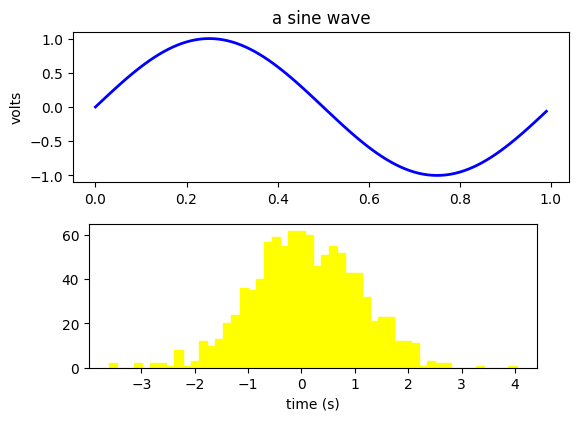

In [39]:
import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure()
fig.subplots_adjust(top=0.8)
ax1 = fig.add_subplot(211)
ax1.set_ylabel('volts')
ax1.set_title('a sine wave')

t = np.arange(0.0, 1.0, 0.01)
s = np.sin(2*np.pi*t)
line, = ax1.plot(t, s, color='blue', lw=2)

# Fixing random state for reproducibility
np.random.seed(19680801)

ax2 = fig.add_axes([0.15, 0.1, 0.7, 0.3])
n, bins, patches = ax2.hist(np.random.randn(1000), 50,
                            facecolor='yellow', edgecolor='yellow')
ax2.set_xlabel('time (s)')

plt.show()

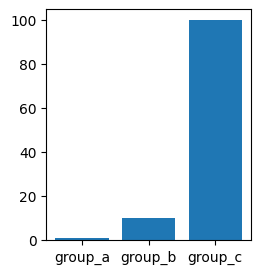

In [40]:
names = ['group_a', 'group_b', 'group_c']
values = [1, 10, 100]

plt.figure(figsize=(9, 3))

plt.subplot(131)
plt.bar(names, values)
plt.show()

#Parte 6 — Experimentos obrigatórios

#"Main"

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

algoritmos = {
    "Bubble Sort": bubble_sort,
    "Insertion Sort": insertion_sort,
    "Merge Sort": merge_sort
}

tamanhos = [1000, 5000, 10000, 50000]
resultados_metricas = []

for n in tamanhos:
    arquivo = f"dados_{n}.csv"
    dados_originais = ler_vetor_csv(arquivo)

    for nome, func in algoritmos.items():
        print(f"Executando {nome} para N={n}...")

        # Evita que um algoritmo receba dados já ordenados (Cópia profunda)
        copia_dados = dados_originais.copy()

        _, tempo = instrumentar_algoritmo(nome, func, copia_dados)
        resultados_metricas.append({"Algoritmo": nome, "N": n, "Tempo (s)": tempo})

# Converter para DataFrame para facilitar a visualização
df_resultados = pd.DataFrame(resultados_metricas)

Executando Bubble Sort para N=1000...
Executando Insertion Sort para N=1000...
Executando Merge Sort para N=1000...
Executando Bubble Sort para N=5000...
{
    "name": "Bubble Sort",
    "context": {
        "trace_id": "0xefe8d06f2a0d2d8c8b87c90d3639ff19",
        "span_id": "0xfe8d4a18ad7b6083",
        "trace_state": "[]"
    },
    "kind": "SpanKind.INTERNAL",
    "parent_id": null,
    "start_time": "2026-03-25T23:27:30.388642Z",
    "end_time": "2026-03-25T23:27:30.438897Z",
    "status": {
        "status_code": "UNSET"
    },
    "attributes": {
        "algoritmo.nome": "Bubble Sort",
        "algoritmo.tamanho_n": 1000,
        "algoritmo.tempo_execucao_s": 0.05008220672607422
    },
    "events": [],
    "links": [],
    "resource": {
        "attributes": {
            "telemetry.sdk.language": "python",
            "telemetry.sdk.name": "opentelemetry",
            "telemetry.sdk.version": "1.38.0",
            "service.name": "unknown_service"
        },
        "schema_u

KeyboardInterrupt: 

In [ ]:
def plotar_resultados(df):
    plt.figure(figsize=(10, 6))
    for algoritmo in df['Algoritmo'].unique():
        subset = df[df['Algoritmo'] == algoritmo]
        plt.plot(subset['N'], subset['Tempo (s)'], marker='o', label=algoritmo)

    plt.title("Desempenho: Tempo x Tamanho da Entrada [cite: 100]")
    plt.xlabel("Tamanho da Entrada (n)")
    plt.ylabel("Tempo (segundos)")
    plt.legend()
    plt.grid(True)
    plt.show()

plotar_resultados(df_resultados)

#Parte 7 — Análise crítica (parte mais importante)

##• Os resultados confirmaram a teoria?
Sim os resultados comprovam o que é visto em teoria, onde algoritmos do Big O maior levam tempos maiores para execução de vetores. Gerando maior consumo e gasto operacional

##• Onde a teoria não explica totalmente o comportamento real?
Onde existem entradas e tamanhos de chamada pequenos, o tempo de execução acaba sendo algo menor e em determinado ponto irrelevante
##• Quando um algoritmo teoricamente pior teve desempenho aceitável?
Em entradas menores ou em caso de parcial ordenação
##• Que fatores além do Big-O influenciaram os resultados?
Nível de embaralhamento do vetor e no caso do Insert a seleção do Pivo
##• O que você não teria percebido sem observabilidade?
O nível de diferença operacional/execução entre um algoritmo O(n²) para um O(n log n)

#Parte 8 — Uso de IA (registro obrigatório)

##• Onde a IA ajudou (implementação, instrumentação, análise)

Escrita dos algoritmos de ordenação, por serem de dominio, onde buscar em sites/repositórios.
Aplicação de algoritmos simples como da geração do CSV, algo de baixa complexidade, mas que pode ser encurtado.
##• Onde ela errou ou foi superficial
Nas respostas ou tentativas de juntar todos os trechos de códigos ou mesmo na maneira de montar as plotagens
##• Onde você precisou corrigir ou decidir sozinho
Durante o processo de plotagem (parte5) e decisão de qual ferramenta usar para esse trecho, bem como a implementação da biblioteca por já ter visto ela a tempo atrás.